In [1]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [2]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

In [1]:
from scipy.io import loadmat
import numpy as np

path = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"

mat = loadmat(path, squeeze_me=True, struct_as_record=False)

def find_arrays(obj, prefix=""):
    if hasattr(obj, "_fieldnames"):  # MATLAB struct
        for f in obj._fieldnames:
            find_arrays(getattr(obj, f), prefix + f + ".")
    elif isinstance(obj, np.ndarray) and np.issubdtype(obj.dtype, np.number):
        print(prefix[:-1], "shape:", obj.shape)

for k in mat:
    if not k.startswith("__"):
        find_arrays(mat[k], k + ".")

aggr_data.nose.eyes shape: (1438300,)
aggr_data.nose.sizepx shape: (1438300,)
aggr_data.nose.theta shape: (1438300,)
aggr_data.nose.time shape: (1438300,)
aggr_data.nose.subj shape: (1438300,)
aggr_data.mouth.eyes shape: (1364781,)
aggr_data.mouth.sizepx shape: (1364781,)
aggr_data.mouth.theta shape: (1364781,)
aggr_data.mouth.time shape: (1364781,)
aggr_data.mouth.subj shape: (1364781,)


In [3]:
from scipy.io import loadmat
import numpy as np
import pandas as pd

path = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"

data = loadmat(path)  
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'aggr_data'])


In [4]:
keys = [k for k in data.keys() if not k.startswith("__")]
print("Variables:", keys)

for k in keys:
    arr = data[k]
    print(k, type(arr), getattr(arr, "shape", None), getattr(arr, "dtype", None))

Variables: ['aggr_data']
aggr_data <class 'numpy.ndarray'> (1, 1) [('nose', 'O'), ('mouth', 'O')]


In [5]:
import numpy as np
import pandas as pd

aggr = data["aggr_data"]  # shape (1,1) struct
nose = aggr["nose"][0, 0]
mouth = aggr["mouth"][0, 0]

print("nose:", type(nose), getattr(nose, "shape", None), getattr(nose, "dtype", None))
print("mouth:", type(mouth), getattr(mouth, "shape", None), getattr(mouth, "dtype", None))

nose: <class 'numpy.ndarray'> (1, 1) [('eyes', 'O'), ('sizepx', 'O'), ('theta', 'O'), ('time', 'O'), ('subj', 'O'), ('gender', 'O')]
mouth: <class 'numpy.ndarray'> (1, 1) [('eyes', 'O'), ('sizepx', 'O'), ('theta', 'O'), ('time', 'O'), ('subj', 'O'), ('gender', 'O')]


In [6]:


aggr = data["aggr_data"]
nose = aggr["nose"][0, 0]
mouth = aggr["mouth"][0, 0]
# ai 
def _unwrap(x):
    # unwrap common MATLAB shapes like (N,1) or (1,N) or (1,1)
    x = np.array(x)
    if x.shape == (1, 1):
        return x[0, 0]
    return x.squeeze()
# ai 
def struct_to_dict(struct_1x1):
    s = struct_1x1[0, 0]  # actual struct element
    out = {}
    for field in s.dtype.names:
        v = _unwrap(s[field])
        out[field] = v
    return out

nose_dict = struct_to_dict(nose)
mouth_dict = struct_to_dict(mouth)

# Make a DataFrame; if values are vectors of same length, pandas makes rows nicely
df_nose_pupil = pd.DataFrame(nose_dict)
df_mouth_pupil = pd.DataFrame(mouth_dict)

# df_nose_pupil.to_csv(r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\nose.csv", index=False)
# df_mouth_pupil.to_csv(r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\mouth.csv", index=False)


# print("df_nose_pupil:", df_nose_pupil.shape)
# print("df_mouth_pupil:", df_mouth_pupil.shape)
print("Nose columns:", df_nose_pupil.columns.tolist())

Nose columns: ['eyes', 'sizepx', 'theta', 'time', 'subj', 'gender']


In [7]:
df_nose_pupil.head()

,eyes,sizepx,theta,time,subj,gender
0,0.846261,28.75981,0.000000,0.77197,11,M
1,0.866040,28.88967,1.910112,0.78808,11,M
2,0.897213,29.09433,3.707865,0.80468,11,M
3,0.847429,28.76748,5.617978,0.82080,11,M
4,0.893561,29.07035,7.415730,0.83740,11,M


In [8]:
s = df_nose_pupil['subj'].unique()
print(len(s))
s

89


array([ 11,  12,  13,  14,  16,  17,  18,  19,  20,  21,  22,  24,  25,
        26,  27,  28,  29,  31,  33,  34,  35,  36,  38,  39,  41,  42,
        43,  44,  45,  46,  47,  48,  50,  51,  53,  54,  55,  56,  57,
        58,  59,  61,  62,  63,  65,  66,  67,  68,  69,  70,  71,  72,
        73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  86,
        87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  99, 100,
       102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112], dtype=uint8)

In [9]:
df_nose_pupil['subj'].value_counts().sort_index()

subj
11     11438
12     16715
13     17343
14     16429
16     17464
       ...  
108    18306
109    16540
110    17720
111    17526
112    16403
Name: count, Length: 89, dtype: int64

In [10]:
from scipy.io import loadmat
import numpy as np

pupil_path = r"C:\Users\saber\thesis_second_try\data\Rest\Pupil_Preprocessed\aggregated_data_combined.mat"

m = loadmat(pupil_path, squeeze_me=True, struct_as_record=False)

aggr = m["aggr_data"]

nose = aggr.nose
mouth = aggr.mouth

# Example: get pupil size signal
pupil_size = np.asarray(nose.sizepx).squeeze()

print(type(pupil_size))
print(pupil_size.shape)

<class 'numpy.ndarray'>
(1438300,)


In [ ]:
import numpy as np

pupil = np.asarray(nose.sizepx).squeeze()

# make sure it's 1D
pupil = pupil.reshape(-1)

WIN_LEN = 2048
N_WINDOWS = 9

need = WIN_LEN * N_WINDOWS
print("pupil length:", len(pupil), "need:", need)

pupil = pupil[:need] 
windows = pupil.reshape(N_WINDOWS, WIN_LEN)  # (9, 2046)

X_pupil = windows[:, None, :]  # (9, 1, 2046)
print("X_pupil:", X_pupil.shape)

pupil length: 1438300 need: 18432
X_pupil: (9, 1, 2048)


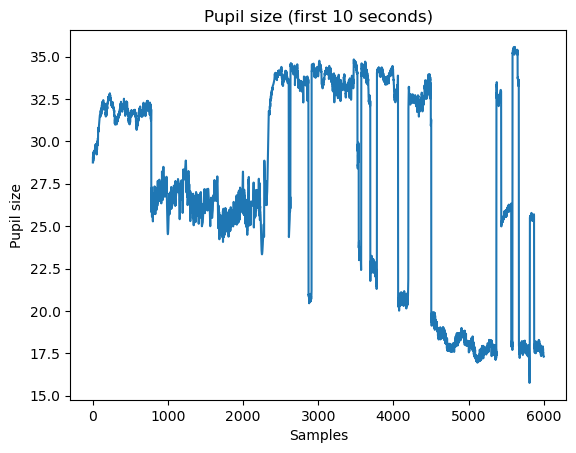

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fs_out = 60
seconds = 100
n = fs_out * seconds

pupil = np.asarray(nose.sizepx).squeeze()

plt.figure()
plt.plot(pupil[:n])
plt.title("Pupil size (first 100 seconds)")
plt.xlabel("Samples")
plt.ylabel("Pupil size")
plt.show()

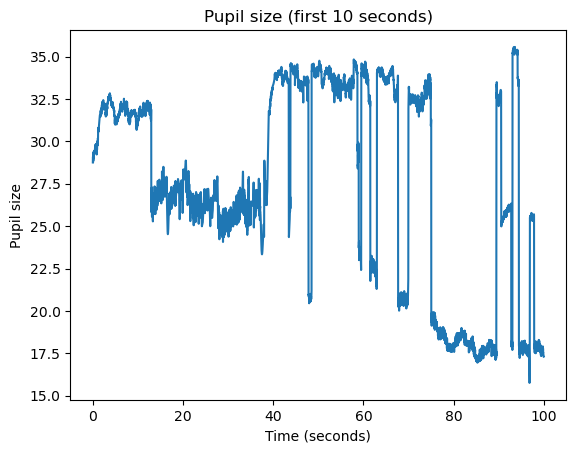

In [13]:
time = np.arange(n) / fs_out

plt.figure()
plt.plot(time, pupil[:n])
plt.title("Pupil size (first 10 seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Pupil size")
plt.show()